# AM10: Computing for Science and Engineering

# Lab 12

### Fall 2020


## Module: Advanced

### Learning objectives:
Random walks and diffusion. Partial differential equations: the diffusion equation in 1 and in 2 spatial dimensions.

_______________________________________________________________________________________________________________________________

In [2]:
import numpy as np
import matplotlib.pyplot as plt

___________________________________________________________________________________________________________________________

## The diffusion equation

The **diffusion equation** is a **second order partial differential equation** involving a first-order time derivative (i.e. $\frac {\partial u}{\partial t}$) but second-order spatial derivatives (i.e. $\frac {\partial^2 u}{\partial x^2} $, $\frac {\partial^2 u}{\partial y^2} $). 


### The one-dimensional (1D) diffusion equation:

In one dimension (1D) the diffusion equation is expressed as:
$$\frac {\partial u}{\partial t} = D \frac {\partial^2 u}{\partial x^2} $$

where $u = u(x, t)$ describes the value of the physical quantity (e.g. density, temperature, etc) we are studying in the spatial location x at time t; $D$ is the diffusion coefficient (in this Lab's problems, it is considered constant). 

The function $u$ may describe a temperature profile, the density of particles, etc. 

As with all partial differential equations (PDEs), in order to solve it we need to define specific boundary conditions (for the function $u$ at the $x$ bounds) as well as initial conditions (at $t=0$).

Applying finite difference approximations (forward difference for $\frac {\partial u}{\partial t}$, and central difference for $\frac {\partial ^2 u}{\partial x^2}$) the 1-dimensional (1D) diffusion equation becomes:

$$\frac {u^{(n+1)}_{i}−u^{(n)}_{i}}{Δt} = D \big [ \frac{u^{(n)}_{i+1}−2u^{(n)}_{i} + u^{(n)}_{i−1}}{(Δx)^2} \big ]$$

where $(n+1)$ is the index of the time step n+1 (similarly, $(n)$ is the index for time step n), $i+1$ is the index of the x-point $x_{i+1}$ and so on. Thus, the state of the system at time step n+1, $u^{(n+1)}_{i}$, is calculated from its state at time step n, $u^{(n)}_{i}$, by the equation 

$$u^{(n+1)}_{i}=u^{(n)}_{i} +D Δt \big [ \frac{u^{(n)}_{i+1}−2u^{(n)}_{i}+u^{(n)}_{i−1}}{(Δx)^2} \big ]$$

This equation can also be expressed as:

$$u[i]=u0[i] +D \ Δt \ \big ( \frac{u0[i+1]−2u0[i]+u0[i-1]}{(Δx)^2} \big )$$

where $u0$ is the $u$ array at the *previous* time-point.

It can be proven that the *maximum* value of the time step Δt that can be considered without the method becoming unstable is
$$Δt=\frac{(Δx)^2}{2D}$$

### The two-dimensional (2D) diffusion equation:
The two-dimensional (2D) diffusion equation is expressed as:
$$\frac {\partial u}{\partial t} = D \big (\frac {\partial^2 u}{\partial x^2} + \frac {\partial^2 u}{\partial y^2} \big )$$ 
where $D$ is the diffusion coefficient (here, we have taken $D$ to be the same for both dimensions; however $D$ can be of different value for each dimension). 

Applying finite difference approximations (forward difference for $\frac {\partial u}{\partial t}$, and central difference for $\frac {\partial ^2 u}{\partial x^2}$, and for $\frac {\partial ^2 u}{\partial y^2}$), the 2D diffusion equation becomes:

$$\frac {u^{(n+1)}_{i,j}−u^{(n)}_{i,j}}{Δt} = D \big [ \frac{u^{(n)}_{i+1,j}−2u^{(n)}_{i,j} + u^{(n)}_{i−1,j}}{(Δx)^2} + \frac{u^{(n)}_{i,j+1}−2u^{(n)}_{i,j}+u^{(n)}_{i,j−1}}{(Δy)^2} \big ]$$

and, thus, the state of the system at time step n+1, $u^{(n+1)}_{i,j}$, is calculated from its state at time step n, $u^{(n)}_{i,j}$, by the equation 

$$u^{(n+1)}_{i,j}=u^{(n)}_{i,j} +D Δt \big [ \frac{u^{(n)}_{i+1,j}−2u^{(n)}_{i,j}+u^{(n)}_{i−1,j}}{(Δx)^2} +\frac{u^{(n)}_{i,j+1}−2u^{(n)}_{i,j}+u^{(n)}_{i,j−1}}{(Δy)^2} \big ]$$

This equation can also be expressed as:

$$u[i,j]=u0[i,j] + D \ Δt \ \big ( \frac{u0[i+1,j]−2u0[i,j]+u0[i−1,j]}{(Δx)^2} +\frac{u0^[i,j+1]−2u0[i,j]+u0[i,j−1]}{(Δy)^2} \big )$$

where $u0[i,j]$ is the (two-dimensional) $u[i,j]$ array at the *previous* time-point.

It can be proven that the *maximum* value of the time step Δt that can be considered without the method becoming unstable is
$$Δt=\frac{1}{2D} \cdot \frac{(Δx \cdot Δy)^2}{(Δx)^2+(Δy)^2}$$


____________________________________________________________________________________________________________________________

## Functions for solving 1D and 2D diffusion equations

We will start by writing functions for solving the 1D and the 2D diffusion equations by implementing the methods presented above.


## Exercise 1
Write a function `do_timestep` to do a "one time-step" update of the 1D diffusion equation

$$u[i]=u0[i] + D \ Δt \ \big ( \frac{u0[i+1]−2u0[i]+u0[i-1]}{(Δx)^2} \big )$$

where $u0$ is the $u$ array at the *previous* time-point.

The input to the `do_timestep` function will be the $u0$ array (which is the "initial" array of u values; $u0$ is defined *externally* because it depends on the specific problem we have to solve), the diffusion coefficient $D$, $dx$, and $dt$). 

The output of the `do_timestep` function will be the $u$ array. 

In [2]:
def do_timestep(u0, D, dx, dt):
    
    # Propagate with forward-difference in time, central-difference in space
    
    Nx=len(u0)
    
    u[0]=u0[0]
    u[Nx-1]=u0[Nx-1]
    
    for i in range(1, Nx-1):
        
        '''Fill in code for u[i]'''
      #---------------------------------------------
        u[i] = u0[i] + D * dt * (u0[i+1] - 2 * u0[i]+u0[i-1])/(dx**2)
      #---------------------------------------------
    
#    u[1:-1] = u0[1:-1] + F * (u0[2:] - 2*u0[1:-1] + u0[:-2])  # this is another way of getting the same result as 
                                                               # above (using for loop); F = D * dt / (dx**2)


    return u

## Example: Heat conduction in a rod

Assume a rod of length L, the left end of which is at *constant* temperature $T_{x=0} = T_{high} = 325 K$. Initially, the rest of the length of the rod is at room temperature $T_{init} = T_{low} = 273 K$. 

How is the initial temperature profile evolving as time goes on? 

In [3]:
# Set up the parameters of the problem:

xmin=0.
xmax=0.5     # xmax = L, the length of the rod
Nx=100

x=np.linspace(xmin, xmax, Nx)

# dx interval in x-direction (unit: mm)
dx = x[1]-x[0]

# diffusion coefficient (unit: mm^2/s)
D = 0.4

dt = 0.00001

# Initializing u
u = np.zeros(Nx)

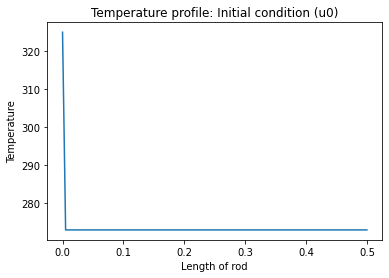

In [4]:
# Set up the initial condition (array u0), and plot it

T_high = 325      # the high temperature, measured in Kelvin (K)
T_low = 273      # the low temperature, measured in Kelvin (K)

# initialize u0
u0 = np.zeros(Nx)

# the initial condition (initial values)
u0[0] = T_high     # higher temperature at the one end  
u0[1:] = T_low    # lower temperature anywhere else

# plot
plt.plot(x,u0)
plt.xlabel('Length of rod')
plt.ylabel('Temperature')
plt.title('Temperature profile: Initial condition (u0)')
plt.show()

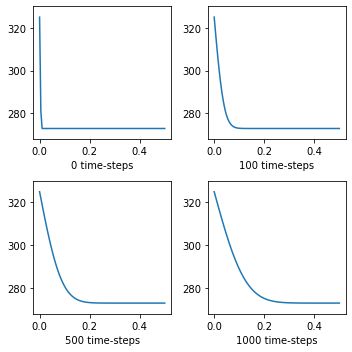

In [5]:
# Time evolution of the diffusion process

# Number of timesteps
nsteps = 1001

# Output 4 figures at these timesteps
time_plots = [0, 100, 500, 1000]
fignum = 0
fig = plt.figure(figsize=(5,5))

for m in range(nsteps):
    
    # call the do_timestep() function
    u = do_timestep(u0, D, dx, dt)
    u0=u
    
    if m in time_plots:
        fignum += 1
        ax = fig.add_subplot(220 + fignum)
        ax.plot(x,u)
        ax.set_ylim(T_low - 5, T_high + 5)
        ax.set_xlabel('{:.0f} time-steps'.format(m))

plt.tight_layout()
plt.show()
    

___________________________________________________________________________________________________________________________

# Team activity (link to your team's breakout room)

## Problem 1 

Solve the 1D diffusion equation for the *time evolution* of the diffusive behavior of the Gaussian distribution

$$ g_{\sigma} (x) = \frac {1}{\sigma \sqrt{2\pi}} e ^ { \frac {-x^2}{2 \sigma ^2}}$$
for $\sigma$=0.5, x in the interval [-5, +5], Nx=100, $D$=4, $dt$ = 0.001, for a total of 201 time-steps (nsteps=201); plot the result obtained, $u$, for t=0, 50, 100, 200 (time_plots=[0,50,100,200]). 

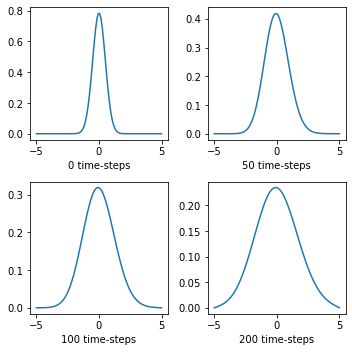

In [8]:
x = np.linspace(-5,5,100)
dx = x[1]-x[0]
D = 4 
dt = 0.001
def Gauss1D(x,sigma):
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-x**2/(2*sigma**2))
# your code here
nsteps = 201

# initialize u0
u0 = np.zeros(100)

# the initial condition (initial values)
u0 = Gauss1D(x,0.5)


# Output 4 figures at these timesteps
time_plots = [0, 50, 100, 200]
fignum = 0
fig = plt.figure(figsize=(5,5))

for m in range(nsteps):
    
    # call the do_timestep() function
    u = do_timestep(u0, D, dx, dt)
    u0=u
    
    if m in time_plots:
        fignum += 1
        ax = fig.add_subplot(220 + fignum)
        ax.plot(x,u)
        ax.set_xlabel('{:.0f} time-steps'.format(m))

plt.tight_layout()
plt.show()



**Return to main room**

__________________________________________________________________________________________________________________________

## Exercise 2
Write a function `do2_timestep` to do a "one time-step" update of the 2D diffusion equation

$$u[i,j]=u0[i,j] + D \ Δt \ \big ( \frac{u0[i+1,j]−2u0[i,j]+u0[i−1,j]}{(Δx)^2} +\frac{u0^[i,j+1]−2u0[i,j]+u0[i,j−1]}{(Δy)^2} \big )$$

where $u0[i,j]$ is the (two-dimensional) $u[i,j]$ array at the *previous* time-point.

The input to the `do2_timestep` function will be the $u0$ array (which is the array of the *previous time-step's* $u$ values; $u0$ is defined *externally*). 

The output of the `do2_timestep` function will be the (updated) $u$ array. 

In [ ]:
def do2_timestep(u0, D, dx, dy, dt):
    
    Nx=len(u0)
    Ny=len(u0[0])

    u[0,0]=u0[0,0]
    u[0,Ny-1]=u0[0,Ny-1]
    u[Nx-1,0]=u0[Nx-1,0]
    u[Nx-1,Ny-1]=u0[Nx-1, Ny-1]
    
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            
    # Propagate with forward-difference in time, central-difference in space  
            '''Fill in code for u[i,j]'''
      #---------------------------------------------
        u[i,j] = u0[i,j]+ D * dt * ((u0[i+1,j]-2*u0[i-1,j])/(dx**2)+D*dt*(u0)
            
      #--------------------------------------------- 

    return u

## Example: Heat conduction in a (2D) metal plate
Consider the diffusion equation applied to a metal plate initially at temperature $T_{cold}$ apart from a disc of a specified size which is at temperature $T_{hot}$. We suppose that the edges of the plate are held fixed at $T_{cool}$. The following code applies the `do2_timestep` to numerically calculate the time evolution of the temperature of the plate. 
[This problem has been adapted from https://scipython.com/book/chapter-7-matplotlib/examples/the-two-dimensional-diffusion-equation/]

In [ ]:
# Thermal diffusivity of plate's material
D = 4.       # (unit of mm^2/s)

# Plate size 
Lx = 10.     # (mm)
Ly = 10.     # (mm)

xmin = 0.
xmax = Lx
ymin = 0.
ymax = Ly

Nx = 100
Ny = 100

x = np.linspace(xmin, xmax, Nx)
y = np.linspace(ymin, ymax, Nx)

# Step size in x-, y- directions, and time-step dt
dx = x[1] - x[0]
dy = y[1] - y[0]

dt = 0.5 * (dx * dx) * (dy * dy) / (2 * D * ((dx * dx) + (dy * dy)))    # to satisfy condition for stability  


# Initial temperatures 
Tcool, Thot = 300, 700     # in Kelvin (K)

# Initialize entire plate in Tcool (but also assign higher temperature, Thot, in inner disc)
u0 = Tcool * np.ones((Nx, Ny))

# Initial condition for disc of inner radius r, centered at point (cx,cy) (mm)
r, cx, cy = Lx/5, Lx/2, Ly/2
r2 = r**2

for i in range(Nx):
    for j in range(Ny):
        p2 = (i*dx-cx)**2 + (j*dy-cy)**2
        if p2 < r2:
            u0[i,j] = Thot

# Initialize u
u = np.zeros((Nx, Ny))
            
# Number of timesteps
nsteps = 101

# Output of four figures (plots of the diffusive behavior) at these timesteps
time_plots = [0, 10, 50, 100]

fignum = 0
fig = plt.figure(figsize=(6,6))

for m in range(nsteps):
    
    u = do2_timestep(u0, D, dx, dy, dt)
    u0=u
    
    if m in time_plots:
        fignum += 1
        ax = fig.add_subplot(220 + fignum)
        im = ax.imshow(u.copy(), cmap=plt.get_cmap('hot'), vmin=Tcool,vmax=Thot)
        ax.set_axis_off()
        ax.set_title('{:.1f} ms'.format(m*dt*1000))
        
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel('$T$ / K', labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

___________________________________________________________________________________________________________________________

# Random walks

# Team activity (link to your team's breakout room)

## Problem 2

In this problem, drunken sailors will perform two types of 1-dimensional random walks:

a) a random walk in which the random steps are taken half-the-time to the right (positive steps) and half-the-time to the left (negative steps), that is the steps are sampled from a uniform (-1,1) distribution;

b) a random walk in which the steps are sampled from the normal `np.random.randn()` distribution.

Consider a company of 50 drunken sailors performing the first type and another company of 50 drunken sailors performing the second random walk type. 

Plot the random walks (for all 50 sailors) in each type (plot them separately) for 100 time-steps, and calculate the mean displacement.  

How far, on average, has each drunken sailor company moved away from the origin?

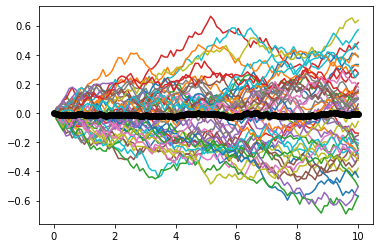

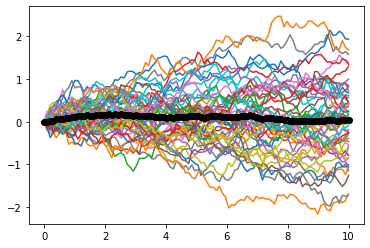

In [5]:
# your code here
tmax = 10
dt = 0.1
num_times = int(tmax/dt)

time = np.linspace(0,tmax,num_times)
r = np.zeros(num_times)

rbias = 0.50

Nsailors = 50
rav = np.zeros(num_times)

for ns in range (Nsailors):
    
    for n in range(1,num_times):
        r[n]=r[n-1]+(np.random.rand()-rbias)*dt
        rav[n]=rav[n]+r[n]
    
    plt.plot(time,r)

rav = rav/Nsailors

plt.plot(time,rav,'ko-',linewidth='1.5')
plt.show()

# Second company 
tmax = 10
dt = 0.1
num_times = int(tmax/dt)

time = np.linspace(0,tmax,num_times)
r = np.zeros(num_times)

rbias = 0.50

Nsailors = 50
rav = np.zeros(num_times)

for ns in range (Nsailors):
    
    for n in range(1,num_times):
        r[n]=r[n-1]+(np.random.randn())*dt
        rav[n]=rav[n]+r[n]
    
    plt.plot(time,r)

rav = rav/Nsailors

plt.plot(time,rav,'ko-',linewidth='1.5')
plt.show()

### Return to main room

___________________________________________________________________________________________________________________________

__________________________________________________________________________________________________________________________